# Lyα forest inversion with the fluctuating Gunn–Peterson approximation

This notebook demonstrates the simplest physically motivated inversion of a Lyα forest spectrum. Starting from a CAMELS gas-density skewer, we will

1. define baryonic and cold-dark-matter overdensities;
2. use the actual CAMELS temperature along the same sightline;
3. generate an intrinsic Lyα forest from the gas density and temperature, then pass it through Gaussian instrumental smoothing and noise;
4. apply the direct pixelwise FGPA inverse to the mock observed flux; and
5. use the approximation that diffuse baryons trace dark matter to construct a DM-density proxy.

The final comparison uses the CAMELS DM field only as validation truth. It is **not** used to calibrate the reconstruction.

> **Scope.** This remains a real-space FGPA experiment: thermal line broadening, peculiar velocities, and continuum errors are omitted. Gaussian instrumental resolution and flux noise are included explicitly so the notebook exposes why a pixel-by-pixel inverse becomes biased. The regularized-MAP and neural notebooks model the same observation settings more effectively.

## 1. Imports and configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.optimize import brentq
from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

data_directory = Path("Sims/CMD_z=2_grid128")
output_directory = Path("figures")
output_directory.mkdir(exist_ok=True)

seed = 0
y_index = 64
z_index = 64
box_size = 25.0  # comoving Mpc/h
box_redshift = 2.0

# === User-adjustable mock-observation settings ===
signal_to_noise = 5.0         # S/N per native flux pixel
instrument_fwhm_kms = 120.0  # Gaussian instrumental FWHM [km/s]
noise_seed = 2026

# === Assumed thermal relation available to the inversion (not the simulator truth) ===
inversion_T0_K = 10_000.0
inversion_gamma = 1.5

## 2. Extract gas, dark-matter, and temperature skewers

The density files contain $27$ simulations with shape

$$(N_{\rm simulation},N_x,N_y,N_z)=(27,128,128,128).$$

We select a line of sight along $x$ by fixing $(y,z)=(64,64)$. For any component $i$, define

$$\Delta_i(x)\equiv\frac{\rho_i(x)}{\bar\rho_i}, \qquad \delta_i(x)\equiv\Delta_i(x)-1.$$

$\Delta$ is the overdensity factor used in most Lyα work; $\delta$ is the density contrast. The denominator is the mean of the complete three-dimensional simulation box, not the mean of this particular skewer. Consequently, the mean of one finite skewer need not equal one.

In [2]:
gas_boxes = np.load(
    data_directory / "Grids_Mgas_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
dm_boxes = np.load(
    data_directory / "Grids_Mcdm_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)
temperature_boxes = np.load(
    data_directory / "Grids_T_IllustrisTNG_CV_128_z=2.0.npy",
    mmap_mode="r",
)

number_of_cells = gas_boxes.shape[1]
cell_size = box_size / number_of_cells
x = (np.arange(number_of_cells) + 0.5) * cell_size

gas_box_mean = gas_boxes[seed].mean(dtype=np.float64)
dm_box_mean = dm_boxes[seed].mean(dtype=np.float64)

rho_gas = gas_boxes[seed, :, y_index, z_index].astype(np.float64)
rho_dm = dm_boxes[seed, :, y_index, z_index].astype(np.float64)
temperature_camels = temperature_boxes[seed, :, y_index, z_index].astype(np.float64)

Delta_b_true = rho_gas / gas_box_mean
Delta_dm_true = rho_dm / dm_box_mean

print(f"Cell width: {cell_size:.3f} comoving Mpc/h")
print(f"3D gas-density mean: {gas_box_mean:.4e} (Msun/h)/(Mpc/h)^3")
print(f"3D CDM-density mean: {dm_box_mean:.4e} (Msun/h)/(Mpc/h)^3")
print(f"Mean Delta_b on this skewer: {Delta_b_true.mean():.3f}")
print(f"Mean Delta_dm on this skewer: {Delta_dm_true.mean():.3f}")

Cell width: 0.195 comoving Mpc/h
3D gas-density mean: 1.3430e+10 (Msun/h)/(Mpc/h)^3
3D CDM-density mean: 6.9665e+10 (Msun/h)/(Mpc/h)^3
Mean Delta_b on this skewer: 0.875
Mean Delta_dm on this skewer: 0.785


Gas and CDM arrays identical: False
Gas–CDM correlation: 0.960; median relative difference: 7.6%


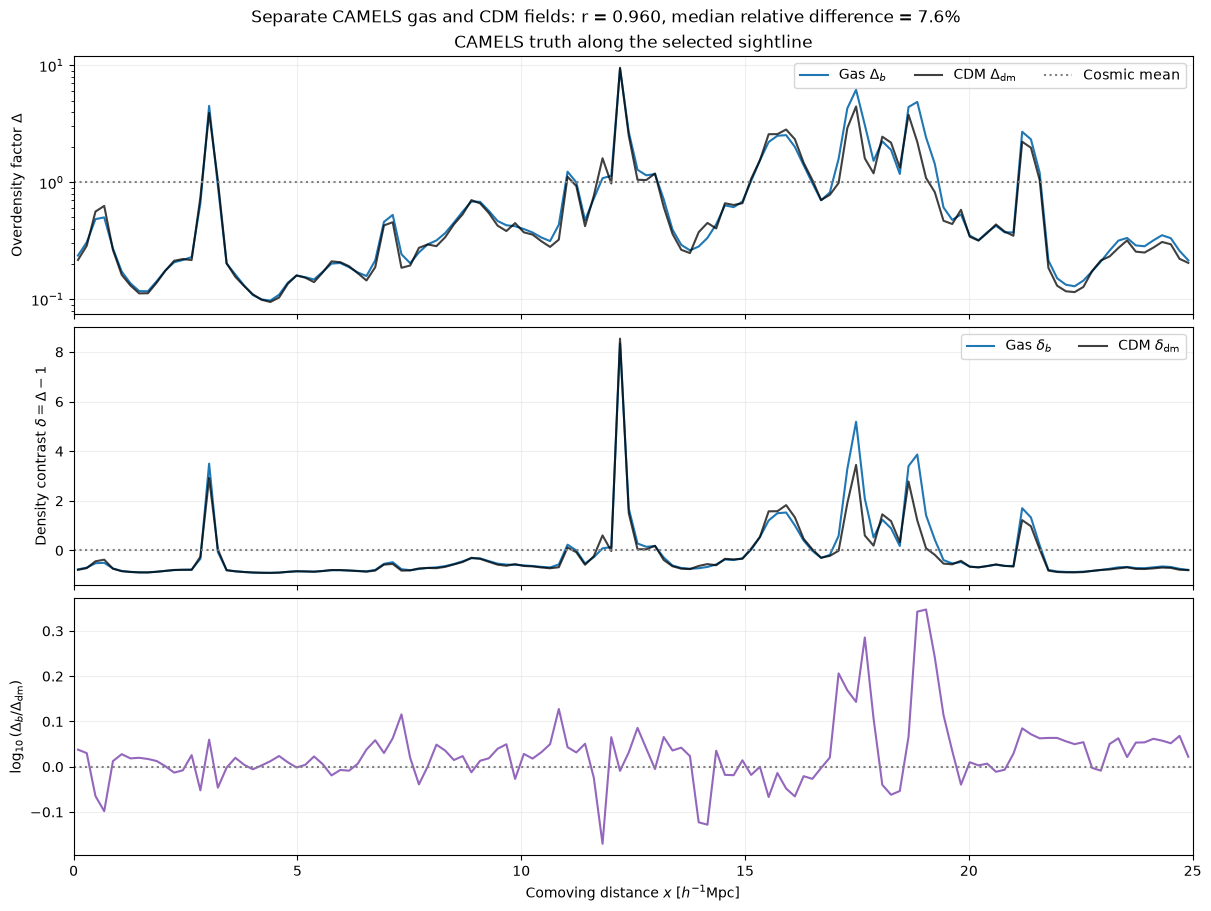

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="tab:blue", label=r"Gas $\Delta_b$")
axes[0].semilogy(x, Delta_dm_true, color="black", alpha=0.75, label=r"CDM $\Delta_{\rm dm}$")
axes[0].axhline(1.0, color="0.5", ls=":", label="Cosmic mean")
axes[0].set_ylabel(r"Overdensity factor $\Delta$")
axes[0].set_title("CAMELS truth along the selected sightline")
axes[0].legend(ncol=3)

axes[1].plot(x, Delta_b_true - 1.0, color="tab:blue", label=r"Gas $\delta_b$")
axes[1].plot(x, Delta_dm_true - 1.0, color="black", alpha=0.75, label=r"CDM $\delta_{\rm dm}$")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel(r"Density contrast $\delta=\Delta-1$")
axes[1].legend(ncol=2)

log_density_ratio = np.log10(Delta_b_true / Delta_dm_true)
axes[2].plot(x, log_density_ratio, color="tab:purple")
axes[2].axhline(0.0, color="0.5", ls=":")
axes[2].set_ylabel(r"$\log_{10}(\Delta_b/\Delta_{\rm dm})$")
axes[2].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

correlation = np.corrcoef(Delta_b_true, Delta_dm_true)[0, 1]
median_relative_difference = np.median(np.abs(Delta_b_true-Delta_dm_true)/Delta_dm_true)
fig.suptitle(f"Separate CAMELS gas and CDM fields: r = {correlation:.3f}, median relative difference = {median_relative_difference:.1%}")
fig.savefig(output_directory / "FGPA_truth_fields.png", dpi=150, bbox_inches="tight")
print(f"Gas and CDM arrays identical: {np.array_equal(Delta_b_true, Delta_dm_true)}")
print(f"Gas–CDM correlation: {correlation:.3f}; median relative difference: {median_relative_difference:.1%}")
plt.show()

Gas and dark matter follow the same large-scale structures, but they are not identical. Gas pressure and feedback redistribute baryons, while the gridded CDM field can retain sharper peaks. This difference will set the accuracy limit of the final DM proxy.

## 3. Use the actual CAMELS temperature field

The temperature cube is sampled at exactly the same $(x,y,z)$ cells as the gas-density skewer. We do **not** replace it with a power-law equation of state. Shocks, feedback, and multiphase gas therefore affect the local recombination factor used to create the mock Lyα forest.

A reference temperature $T_{\rm ref}=10^4$ K is used only to make the temperature factor dimensionless; it is not an imposed temperature.

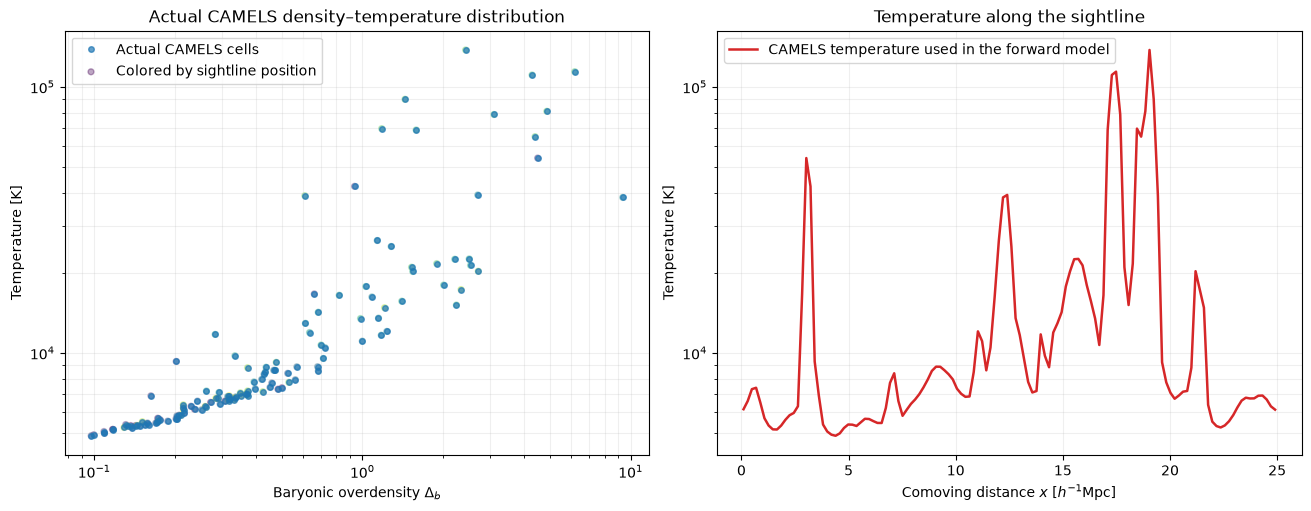

In [4]:
temperature_reference = 10_000.0  # K; normalization only
temperature_factor = (temperature_camels / temperature_reference) ** (-0.7)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].loglog(
    Delta_b_true,
    temperature_camels,
    "o",
    ms=4,
    color="tab:blue",
    alpha=0.7,
    label="Actual CAMELS cells",
)
axes[0].scatter(
    Delta_b_true,
    temperature_camels,
    s=18,
    c=x,
    cmap="viridis",
    alpha=0.35,
    label="Colored by sightline position",
)
axes[0].set_xlabel(r"Baryonic overdensity $\Delta_b$")
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Actual CAMELS density–temperature distribution")
axes[0].legend()
axes[0].grid(alpha=0.2, which="both")

axes[1].semilogy(x, temperature_camels, color="tab:red", lw=1.8, label="CAMELS temperature used in the forward model")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[1].set_ylabel("Temperature [K]")
axes[1].set_title("Temperature along the sightline")
axes[1].legend()
axes[1].grid(alpha=0.2, which="both")

fig.savefig(output_directory / "FGPA_actual_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Forward FGPA: baryonic density to Lyα flux

Photoionization equilibrium gives, schematically,

$$n_{\rm HI}\Gamma_{\rm HI}\simeq n_e n_p\,\alpha_{\rm HII}(T).$$

For highly ionized gas, $n_e n_p\propto\Delta_b^2$, and near $10^4$ K the recombination coefficient scales approximately as $\alpha_{\rm HII}\propto T^{-0.7}$. Therefore

$$n_{\rm HI}\propto\Gamma_{\rm HI}^{-1}\Delta_b^2T^{-0.7}.$$

Using the actual cell temperature in the local Gunn–Peterson relation gives

$$\tau=A\Delta_b^2\left(\frac{T_{\rm CAMELS}}{10^4\,\mathrm K}\right)^{-0.7}, \qquad F=\exp(-\tau).$$

The amplitude $A$ contains the photoionization rate, redshift, cosmology, and baryon abundance. We pre-calibrate it on the other 26 simulation boxes to the illustrative observable mean transmission $\langle F\rangle=0.82$, then hold it fixed for test box 0. No density or temperature from the test sightline enters this calibration. The continuous density–flux picture is described by [Weinberg et al. (1997)](https://arxiv.org/abs/astro-ph/9709303).

In [5]:
target_mean_flux = 0.82
opacity_shape = Delta_b_true**2 * temperature_factor
calibration_simulations = [sim for sim in range(gas_boxes.shape[0]) if sim != seed]
calibration_opacity_shape = np.concatenate([
    (gas_boxes[sim, :, y_index, z_index].astype(np.float64) / gas_boxes[sim].mean(dtype=np.float64))**2
    * (temperature_boxes[sim, :, y_index, z_index].astype(np.float64)/temperature_reference)**(-0.7)
    for sim in calibration_simulations
])

def mean_flux_residual(A):
    return np.mean(np.exp(-A * calibration_opacity_shape)) - target_mean_flux

A_fgpa = brentq(mean_flux_residual, 1.0e-6, 100.0)
optical_depth_fgpa = A_fgpa * opacity_shape
flux_fgpa = np.exp(-optical_depth_fgpa)

H_z = cosmo.H(box_redshift).to_value(u.km/u.s/u.Mpc)
velocity_pixel_width = H_z * (cell_size/cosmo.h) / (1.0+box_redshift)
instrument_sigma_pixels = (
    instrument_fwhm_kms / (2.0*np.sqrt(2.0*np.log(2.0))) / velocity_pixel_width
)
instrument_matrix = ndimage.gaussian_filter1d(
    np.eye(number_of_cells), instrument_sigma_pixels, axis=0, mode="reflect"
)
flux_convolved = instrument_matrix @ flux_fgpa
noise_sigma = 1.0/signal_to_noise
noise_rng = np.random.default_rng(noise_seed)
flux_observed = flux_convolved + noise_rng.normal(0.0, noise_sigma, number_of_cells)

print("Opacity uses the actual CAMELS temperature in every sightline cell")
print(f"FGPA amplitude A = {A_fgpa:.5f}, calibrated on {len(calibration_simulations)} non-test boxes")
print(f"Mean transmitted flux = {flux_fgpa.mean():.5f}")
print(f"Flux range = [{flux_fgpa.min():.3e}, {flux_fgpa.max():.5f}]")
print(f"Instrument FWHM = {instrument_fwhm_kms:.1f} km/s ({instrument_sigma_pixels:.2f} sigma pixels)")
print(f"S/N = {signal_to_noise:.1f} per native pixel; sigma_F = {noise_sigma:.4f}")

Opacity uses the actual CAMELS temperature in every sightline cell
FGPA amplitude A = 0.44503, calibrated on 26 non-test boxes
Mean transmitted flux = 0.80617
Flux range = [2.672e-07, 0.99305]
Instrument FWHM = 120.0 km/s (2.60 sigma pixels)
S/N = 5.0 per native pixel; sigma_F = 0.2000


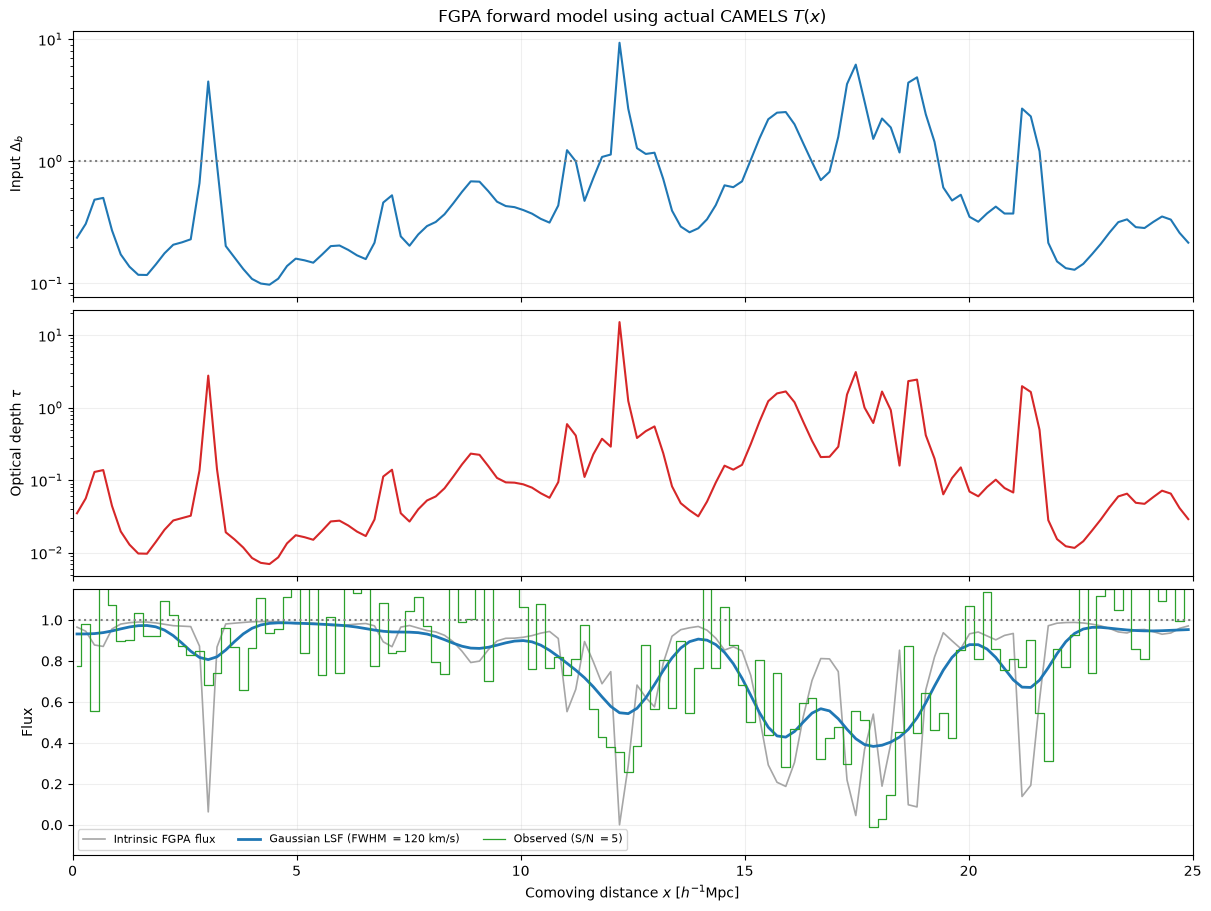

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="tab:blue")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"Input $\Delta_b$")
axes[0].set_title(r"FGPA forward model using actual CAMELS $T(x)$")

axes[1].semilogy(x, optical_depth_fgpa, color="tab:red")
axes[1].set_ylabel(r"Optical depth $\tau$")

axes[2].plot(x, flux_fgpa, color="0.65", lw=1.2, label="Intrinsic FGPA flux")
axes[2].plot(x, flux_convolved, color="tab:blue", lw=2.0, label=rf"Gaussian LSF (FWHM $={instrument_fwhm_kms:.0f}$ km/s)")
axes[2].step(x, flux_observed, where="mid", color="tab:green", lw=.9, label=rf"Observed (S/N $={signal_to_noise:.0f}$)")
axes[2].axhline(1.0, color="0.5", ls=":")
axes[2].set_ylabel("Flux")
axes[2].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")
axes[2].set_ylim(-0.15, 1.15)
axes[2].legend(ncol=3, fontsize=8)

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "FGPA_forward_model.png", dpi=150, bbox_inches="tight")
plt.show()

High-density regions have large optical depth and therefore small transmitted flux. The exponential mapping compresses their dynamic range: once $F$ is close to zero, substantially different overdensities produce nearly indistinguishable absorption. In real noisy spectra this is the familiar saturation problem.

## 5. Apply the direct FGPA inverse to the observed flux

For the ideal local FGPA model, the inverse is algebraic:

$$\tau_{\rm rec}=-\ln F,$$

The observation does not supply $T(x)$, so the inverse adopts the conventional thermal relation $T=T_0\Delta_b^{\gamma-1}$. This gives $\beta=2-0.7(\gamma-1)$ and

$$\boxed{\Delta_{b,\rm rec}=\left[\frac{-\ln F}{A(T_0/10^4\,\mathrm K)^{-0.7}}\right]^{1/\beta}}.$$

This deliberately differs from the simulator, which used the hidden CAMELS temperature field. It also applies the local formula to the **smoothed, noisy** observed flux even though instrumental convolution couples neighbouring pixels. The logarithm requires positive flux, so values are clipped to the noise floor $1/\mathrm{SNR}$; flux above the continuum is clipped just below one. The resulting reconstruction includes both observation effects and thermal-model mismatch.

In [7]:
flux_for_log = np.clip(flux_observed, noise_sigma, 1.0-1.0e-8)
optical_depth_recovered = -np.log(flux_for_log)
inversion_beta = 2.0 - 0.7 * (inversion_gamma - 1.0)
inversion_temperature_normalization = (inversion_T0_K/temperature_reference) ** (-0.7)
Delta_b_recovered = (
    optical_depth_recovered / (A_fgpa * inversion_temperature_normalization)
) ** (1.0/inversion_beta)

fractional_baryon_error = (Delta_b_recovered - Delta_b_true) / Delta_b_true

print(f"Pixels below the noise floor: {np.count_nonzero(flux_observed < noise_sigma)}")
print(f"Pixels at or above the continuum: {np.count_nonzero(flux_observed >= 1.0)}")
print(f"Inversion assumes T0={inversion_T0_K:.0f} K, gamma={inversion_gamma:.2f}, beta={inversion_beta:.3f}")
print(f"Baryon RMSE: {np.sqrt(np.mean((Delta_b_recovered-Delta_b_true)**2)):.3f}")
print(f"Baryon MAE: {np.mean(np.abs(Delta_b_recovered-Delta_b_true)):.3f}")

Pixels below the noise floor: 3
Pixels at or above the continuum: 37
Inversion assumes T0=10000 K, gamma=1.50, beta=1.650
Baryon RMSE: 1.146
Baryon MAE: 0.605


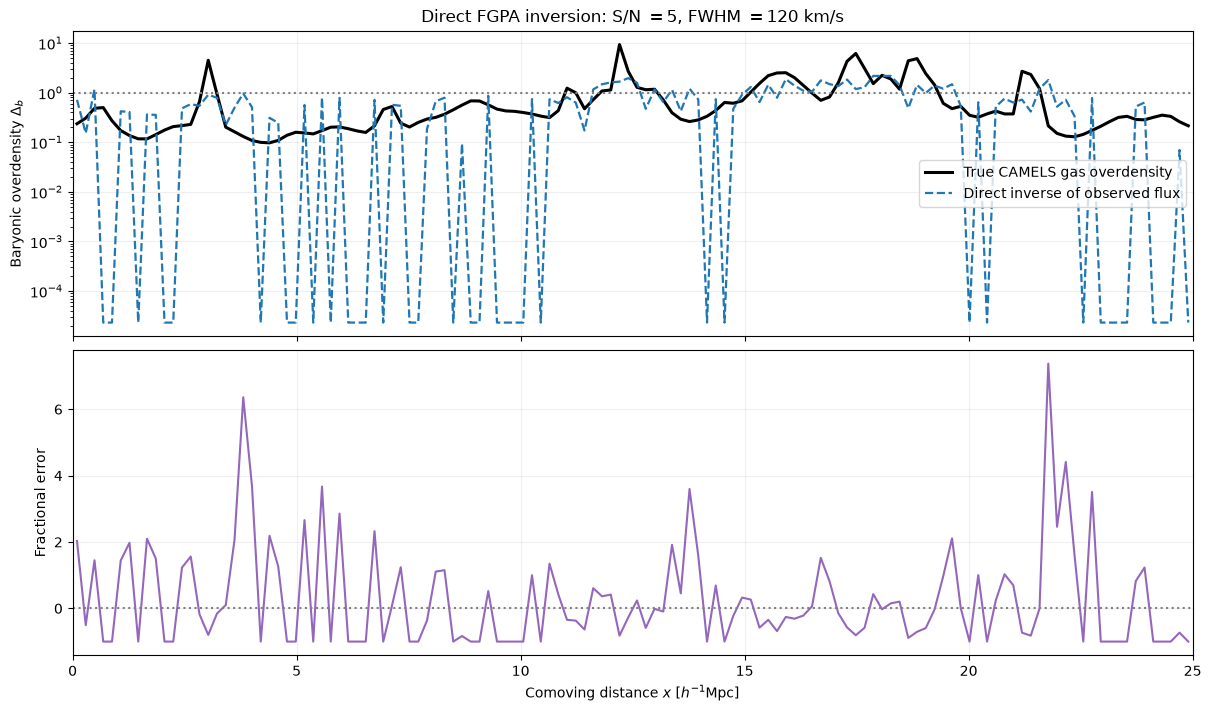

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_b_true, color="black", lw=2.2, label="True CAMELS gas overdensity")
axes[0].semilogy(x, Delta_b_recovered, "--", color="tab:blue", lw=1.6, label="Direct inverse of observed flux")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"Baryonic overdensity $\Delta_b$")
axes[0].set_title(rf"Direct FGPA inversion: S/N $={signal_to_noise:.0f}$, FWHM $={instrument_fwhm_kms:.0f}$ km/s")
axes[0].legend()

axes[1].plot(x, fractional_baryon_error, color="tab:purple")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel("Fractional error")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "FGPA_baryon_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

The direct reconstruction is no longer exact: Gaussian smoothing mixes neighbouring flux pixels, noise is amplified by $-\ln F$, continuum-crossing pixels are clipped, and saturated pixels are limited by the noise floor. This motivates the forward-modelled MAP and simulation-trained neural inversions. The next DM step adds the further approximation that baryons trace CDM.

## 6. From baryonic overdensity to a dark-matter proxy

Lyα absorption is produced by neutral hydrogen, not dark matter. To obtain a DM estimate, we now make the additional approximation

$$\delta_{\rm dm}\simeq\delta_b,$$

or, because both fields are normalized by their own cosmic means,

$$\boxed{\Delta_{\rm dm,pred}\simeq\Delta_{b,\rm rec}}.$$

This is reasonable for diffuse matter on scales where pressure and feedback do not strongly separate gas from dark matter. It is not exact on small or highly nonlinear scales. Importantly, the CAMELS DM truth is not used in this prediction.

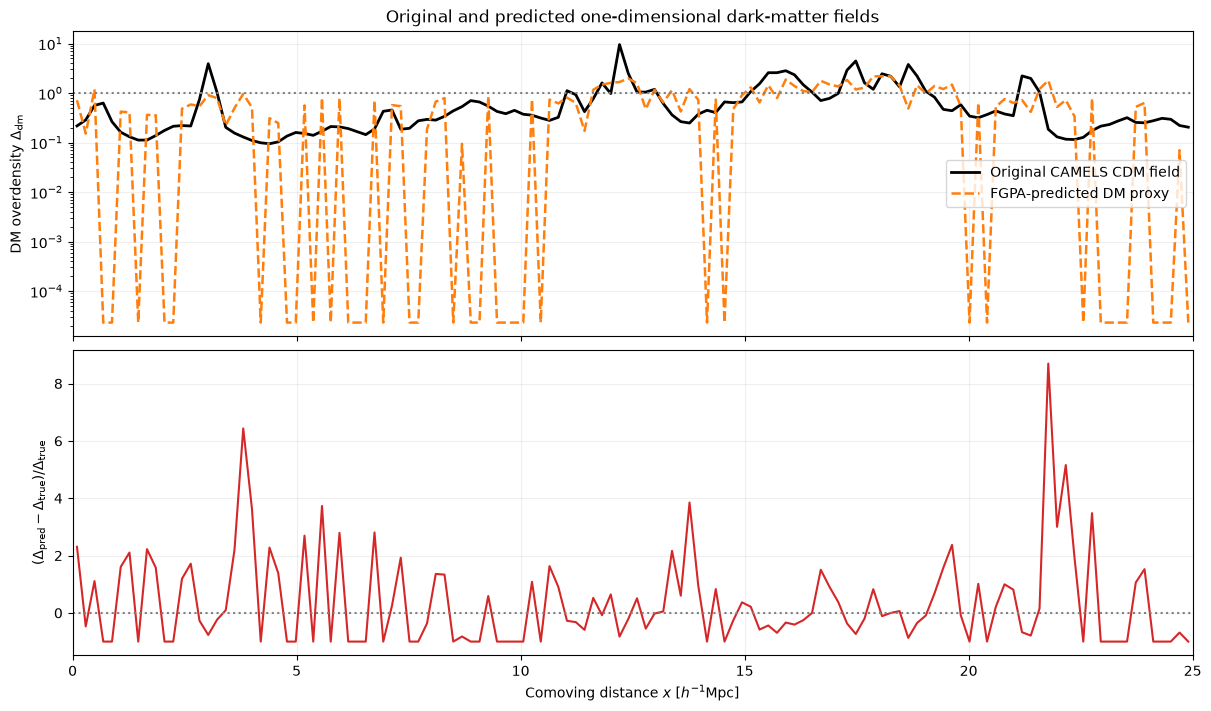

In [9]:
Delta_dm_predicted = Delta_b_recovered.copy()
dm_fractional_residual = (Delta_dm_predicted - Delta_dm_true) / Delta_dm_true

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

axes[0].semilogy(x, Delta_dm_true, color="black", lw=2.0, label="Original CAMELS CDM field")
axes[0].semilogy(x, Delta_dm_predicted, "--", color="tab:orange", lw=1.8, label="FGPA-predicted DM proxy")
axes[0].axhline(1.0, color="0.5", ls=":")
axes[0].set_ylabel(r"DM overdensity $\Delta_{\rm dm}$")
axes[0].set_title("Original and predicted one-dimensional dark-matter fields")
axes[0].legend()

axes[1].plot(x, dm_fractional_residual, color="tab:red")
axes[1].axhline(0.0, color="0.5", ls=":")
axes[1].set_ylabel(r"$(\Delta_{\rm pred}-\Delta_{\rm true})/\Delta_{\rm true}$")
axes[1].set_xlabel(r"Comoving distance $x\ [h^{-1}{\rm Mpc}]$")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.set_xlim(0.0, box_size)

fig.savefig(output_directory / "FGPA_dm_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compare field-level and summary statistics

An overplotted field is useful, but it does not fully describe agreement. We therefore compare four complementary summaries:

- a cell-by-cell parity plot;
- the one-point probability distribution of $\log_{10}\Delta$;
- the one-dimensional power spectrum of $\delta=\Delta-1$; and
- the mean, median, standard deviation, and 90th percentile.

These statistics come from only one 128-cell sightline and are illustrative, not precision estimates.

In [10]:
pearson_r = np.corrcoef(Delta_dm_true, Delta_dm_predicted)[0, 1]
rmse = np.sqrt(np.mean((Delta_dm_predicted - Delta_dm_true) ** 2))
mae = np.mean(np.abs(Delta_dm_predicted - Delta_dm_true))
mean_bias = np.mean(Delta_dm_predicted - Delta_dm_true)

def one_dimensional_power(Delta, spacing):
    """Return P_1D(k)=|dx FFT(delta)|^2/L, omitting the zero mode."""
    density_contrast = Delta - 1.0
    fourier_amplitude = spacing * np.fft.rfft(density_contrast)
    k = 2.0 * np.pi * np.fft.rfftfreq(Delta.size, d=spacing)
    power = np.abs(fourier_amplitude) ** 2 / (Delta.size * spacing)
    return k[1:], power[1:]

k_true, power_true = one_dimensional_power(Delta_dm_true, cell_size)
k_pred, power_pred = one_dimensional_power(Delta_dm_predicted, cell_size)

statistic_names = ["Mean", "Median", "Std. dev.", "90th pct."]
statistics_true = [
    np.mean(Delta_dm_true),
    np.median(Delta_dm_true),
    np.std(Delta_dm_true),
    np.percentile(Delta_dm_true, 90),
]
statistics_predicted = [
    np.mean(Delta_dm_predicted),
    np.median(Delta_dm_predicted),
    np.std(Delta_dm_predicted),
    np.percentile(Delta_dm_predicted, 90),
]

print(f"Pearson correlation r = {pearson_r:.4f}")
print(f"RMSE in Delta_dm = {rmse:.4f}")
print(f"MAE in Delta_dm = {mae:.4f}")
print(f"Mean bias (predicted - true) = {mean_bias:.4f}")

Pearson correlation r = 0.5001
RMSE in Delta_dm = 0.9993
MAE in Delta_dm = 0.5411
Mean bias (predicted - true) = -0.1474


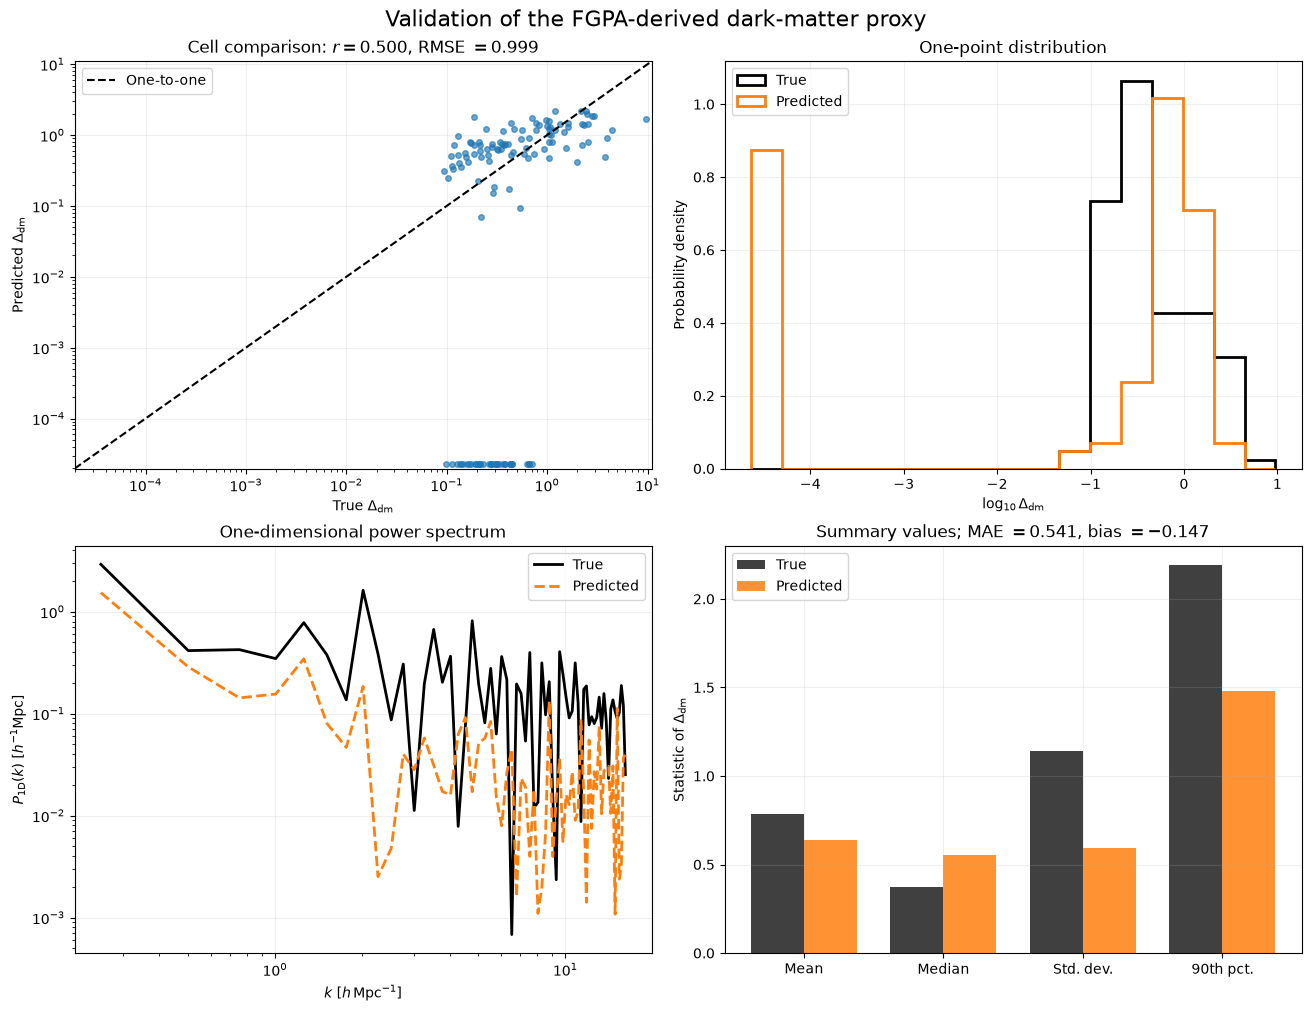

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

limits = [
    min(Delta_dm_true.min(), Delta_dm_predicted.min()) * 0.85,
    max(Delta_dm_true.max(), Delta_dm_predicted.max()) * 1.15,
]
axes[0, 0].loglog(Delta_dm_true, Delta_dm_predicted, "o", ms=4, alpha=0.65, color="tab:blue")
axes[0, 0].plot(limits, limits, "--", color="black", label="One-to-one")
axes[0, 0].set_xlim(limits)
axes[0, 0].set_ylim(limits)
axes[0, 0].set_xlabel(r"True $\Delta_{\rm dm}$")
axes[0, 0].set_ylabel(r"Predicted $\Delta_{\rm dm}$")
axes[0, 0].set_title(rf"Cell comparison: $r={pearson_r:.3f}$, RMSE $={rmse:.3f}$")
axes[0, 0].legend()

log_limits = [
    min(np.log10(Delta_dm_true).min(), np.log10(Delta_dm_predicted).min()),
    max(np.log10(Delta_dm_true).max(), np.log10(Delta_dm_predicted).max()),
]
bins = np.linspace(*log_limits, 18)
axes[0, 1].hist(np.log10(Delta_dm_true), bins=bins, density=True, histtype="step", lw=2.0, color="black", label="True")
axes[0, 1].hist(np.log10(Delta_dm_predicted), bins=bins, density=True, histtype="step", lw=2.0, color="tab:orange", label="Predicted")
axes[0, 1].set_xlabel(r"$\log_{10}\Delta_{\rm dm}$")
axes[0, 1].set_ylabel("Probability density")
axes[0, 1].set_title("One-point distribution")
axes[0, 1].legend()

axes[1, 0].loglog(k_true, power_true, color="black", lw=2.0, label="True")
axes[1, 0].loglog(k_pred, power_pred, "--", color="tab:orange", lw=2.0, label="Predicted")
axes[1, 0].set_xlabel(r"$k\ [h\,{\rm Mpc}^{-1}]$")
axes[1, 0].set_ylabel(r"$P_{1\rm D}(k)\ [h^{-1}{\rm Mpc}]$")
axes[1, 0].set_title("One-dimensional power spectrum")
axes[1, 0].legend()

bar_positions = np.arange(len(statistic_names))
bar_width = 0.38
axes[1, 1].bar(bar_positions - bar_width / 2, statistics_true, bar_width, color="black", alpha=0.75, label="True")
axes[1, 1].bar(bar_positions + bar_width / 2, statistics_predicted, bar_width, color="tab:orange", alpha=0.85, label="Predicted")
axes[1, 1].set_xticks(bar_positions, statistic_names)
axes[1, 1].set_ylabel(r"Statistic of $\Delta_{\rm dm}$")
axes[1, 1].set_title(rf"Summary values; MAE $={mae:.3f}$, bias $={mean_bias:+.3f}$")
axes[1, 1].legend()

for ax in axes.flat:
    ax.grid(alpha=0.2)

fig.suptitle("Validation of the FGPA-derived dark-matter proxy", fontsize=16)
fig.savefig(output_directory / "FGPA_summary_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. What this experiment establishes—and what it does not

- **Baryon inversion:** the simulator uses actual CAMELS temperatures, while the inverse uses only flux plus an assumed $T_0$–$\gamma$ relation. It therefore contains a realistic thermal-model mismatch in addition to instrumental smoothing and noise.
- **Temperature:** the hidden CAMELS temperature is never supplied to the inverse. The editable $T_0$ and $\gamma$ parameters represent external thermal assumptions that would be required for observational data.
- **Dark matter:** the DM result follows only after assuming $\Delta_{\rm dm}\simeq\Delta_b$. Differences from CAMELS truth measure the failure of this tracing approximation on the resolved skewer.
- **Normalization:** $A$ is degenerate with the hydrogen photoionization rate, cosmology, and mean baryon density. Fixing the mean flux supplies the normalization in this demonstration.
- **Real spectra:** this notebook includes finite instrumental resolution and Gaussian noise, but thermal broadening, peculiar velocities, and continuum uncertainty remain absent. These effects require still richer forward modelling and regularization.
- **Regime of validity:** FGPA works best in the diffuse, photoionized IGM. Shocks, self-shielding, galactic environments, and feedback cause departures, especially at high density. A direct comparison of FGPA with hydrodynamical simulations at $z=2$ is given by [Kooistra, Lee & Horowitz (2022)](https://arxiv.org/abs/2201.10169).

### Suggested exercises

1. Vary the inversion assumptions `inversion_T0_K` and `inversion_gamma` and examine the resulting density bias. Separately vary $A$ to represent an incorrect photoionization-rate normalization.
2. Apply a flux floor such as $F_{\rm min}=0.02$ and show that saturated regions become lower limits.
3. Change `signal_to_noise` and `instrument_fwhm_kms` in the first code cell and quantify how the local algebraic inverse degrades.
4. Repeat the analysis for several CAMELS skewers and compare the distribution of correlation coefficients and power-spectrum ratios.